# REDUCCIÓN DE LA DIMENSIONALIDAD

Este notebook trata de reducir el número de variables en nuestro estudio para poder aplicar los distintos modelos posteriores. Transformamos nuestras variables explicativas correlacionadas en un conjunto de componentes ortogonales e independientes. Actuarialmente, esto nos permite sintetizar la información redundante del asegurado en "Perfiles de Riesgo" puros, garantizando que nuestros modelos de reservas posteriores (GLM y BNN) sean matemáticamente estables, no sufran de multicolinealidad y generen estimaciones de incertidumbre fiables para Solvencia II.

En el paso anterior hemos visto que la correlación entre variables numéricas era muy baja con alguna excepción aislada. Esto nos garantiza que nuestros modelos no caerían en multicolinealidad en el caso de usar solamente estas variables. Sin embargo, las variables categóricas contienen información de gran relevancia que será necesaria para obtener la mejor de las estimaciones. 

Debemos comprobar si tiene sentido realizar esta reducción de la dimensionalidad. Para ello y para la futura reducción de la dimensionalidad hay algunas transformaciones de variables que debemos hacer: estandarizar las variables numéricas o reescalar de 0 a 1; codificar las variables categoricas nominales y ordnarias ( comprobar si son nominales algunas como el tipo de auto -> Lujo = Más caro).

### 1. - Transformación de variables numéricas

Los algoritmos que vamos a usar para reducir la sensibilidad son muy sensibles a la escala de nuestros datos, es por ello que decidimos estandarizar las variables numéricas para evitar que los valores mayores de `Customer Lifetime Value` dominen sobre los valores menores que toman otras variables como `Number of Open Complaints`.

Se opta por la estandarización por encima de otros métodos como un reescalado min-max 0-1 para no interferir de una manera artificial sobre la varianza de nuestras variables.

Dentro de las variables predictoras numéricas encontramos dos, que según hemos visto en la exploración de datos, tienen una cola muy pesada a la derecha: `Customer Lifetime Value` y `Monthly Premium Auto`. Antes de estandarizar estas variables debemos transformarlas para asemejarla lo máximo posible a una campana de Gauss. Si usaramos la estandarización directamente sobre estas variables el valor de la media se vería muy distorsionado por los valores gigantes que toma. Para evitar esta situación, optamos por una transformación logarítmica. Esta tansformación comprime los valores que toman estas variables de cola larga, que si bien son valores de interés en el ámbito actuarial al ser extremos, son valores de variables predictoras y no de la variable dependiente. Es por ello que tenemos una mayor libertad de hacer este tratamiento, por último una justificación práctica de la transformación que será necesaria para realizar correctamente la posterior segmentacuón, sería pensar en como nuestro modelo ve a los "clientes", el algoritmo clasificaría a cada uno de los "clientes gigantes" en grupos independientes y dejaría un grupo con la gran mayoría de clientes que toman valores pequeños o medianos enestas variables. Al hacer la transformación logarítmica esperamos clasificar a todos los clientes masivos en el mismo grupo si corresponde o en grupos con otros clientes que correspondan.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo
from scipy.stats import f_oneway
from scipy.stats import chi2
import math
import prince
from functools import reduce

import sys
import os


In [3]:
df = pd.read_csv('../data/processed/df_limpio.csv')
num_cols = ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 
            'Months Since Last Claim', 'Months Since Policy Inception', 
            'Number of Open Complaints', 'Number of Policies']


X_num = df[['Customer', *num_cols]].copy()

cols_asim = ['Customer Lifetime Value', 'Monthly Premium Auto']

# Creamos las variables transformadas por la transformación logarítmica
for col in cols_asim:
    X_num[f'{col}_log'] = np.log1p(X_num[col])

X_num = X_num.drop(columns = cols_asim)

# Hacemos la estandarización de las variables
fnum_cols = [col for col in X_num.columns if col != 'Customer']
scaler = StandardScaler()
X_num_scaled_values = scaler.fit_transform(X_num[fnum_cols])

X_num_final = pd.DataFrame(X_num_scaled_values, columns=fnum_cols, index=X_num.index)
X_num_final.insert(0, 'Customer', X_num['Customer'])

# Mostramos algunos estadísticos de las variables estandarizadas
print("--- ESTADÍSTICAS TRAS TRANSFORMACIÓN LOGARÍTMICA Y ESTANDARIZACIÓN ---")


sum = 0
for col in fnum_cols:
    print('_____________________________________________________________')
    print(f'Variable: {col.upper()}') 
    
    media = X_num_final[col].mean()
    desv  = X_num_final[col].std()
    minimo = X_num_final[col].min()
    maximo = X_num_final[col].max()

    print(f'Media: {media:.4f},    sd: {desv:.4f},    Rango: ({minimo:.4f}, {maximo:.4f})')



--- ESTADÍSTICAS TRAS TRANSFORMACIÓN LOGARÍTMICA Y ESTANDARIZACIÓN ---
_____________________________________________________________
Variable: INCOME
Media: -0.0000,    sd: 1.0001,    Rango: (-1.2319, 2.0578)
_____________________________________________________________
Variable: MONTHS SINCE LAST CLAIM
Media: -0.0000,    sd: 1.0001,    Rango: (-1.4998, 1.9759)
_____________________________________________________________
Variable: MONTHS SINCE POLICY INCEPTION
Media: 0.0000,    sd: 1.0001,    Rango: (-1.7226, 1.8256)
_____________________________________________________________
Variable: NUMBER OF OPEN COMPLAINTS
Media: 0.0000,    sd: 1.0001,    Rango: (-0.4230, 5.0684)
_____________________________________________________________
Variable: NUMBER OF POLICIES
Media: 0.0000,    sd: 1.0001,    Rango: (-0.8236, 2.5207)
_____________________________________________________________
Variable: CUSTOMER LIFETIME VALUE_LOG
Media: -0.0000,    sd: 1.0001,    Rango: (-1.8393, 3.9510)
____________

### 2. - Transformación de Variables categóricas

Debemos asignar un valor numérico a las variables que se expresan en atributos como el tipo de vehículo asegurado. Para ello debemos distinguir entre las variables categóricas nominales y las ordinales:

- **Variables Categóricas Nominales.** Usaremos el _One-Hot Encoding_ de forma que para cada una de estas variables crearemos tantas nuevas variables como atributos distintos pueda adoptar la variable original. Cada una de estas nuevas variables asociadas a los atributos serán binarias que adoptarán el valor 1 para indicar la pertenencia a este nivel o 0 en caso contrario.

- **Variables Categóricas Ordinales.** Otras variables establecen una jeraquía clara entre las distintas clases que conforman la variable, por ejemplo el nivel de educación adquirido. Es por ello que a la hora de codificar estas variables lo hacemos en una nueva variable que adopte valores que reflejen los distintos niveles con un incremento entre cada nivel.

Antes de proceder con la codificación, vamos a ver cuales de nuestras variables categóricas tiene sentido incluir en el PCA, estas son las que tienen un poder predictivo real sobre el `Total Claim Amount`; las variables cuyos niveles tienen similar severidad total no serán de utilidad a la hora de predecir la variable objetivo. Para ello vamos a realizar un test ANOVA.

In [4]:
target = 'Total Claim Amount'
cat_cols = ['State', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 
            'Policy Type', 'Vehicle Class', 'Coverage', 'Education', 'Vehicle Size']

anova_results = []
for col in cat_cols:
    # Agrupamos los valores del Total Claim Amount por cada categoría de la variable
    groups = [df[target][df[col] == category].values for category in df[col].unique()]
    
    # Test ANOVA unilateral
    f_stat, p_val = f_oneway(*groups)
    
    # Calculamos la diferencia máxima de medias de la severidad
    means = df.groupby(col)[target].mean()
    max_diff = means.max() - means.min()
    
    anova_results.append({
        'Variable': col, 
        'F-Statistic': f_stat, 
        'p-value': p_val, 
        'Dif_Max_Min_USD': max_diff
    })

# Damos formato y analizamos los resultados
res_df = pd.DataFrame(anova_results).sort_values('F-Statistic', ascending=False)
res_df['Significativo (p < 0.05)'] = res_df['p-value'] < 0.05 # Significatividad al 95%

print("--- IMPACTO ESTADÍSTICO DE VARIABLES CATEGÓRICAS EN LA SEVERIDAD (ANOVA) ---")
display(res_df.round(2).reset_index(drop=True))

vars_to_drop = res_df[res_df['Significativo (p < 0.05)'] == False]['Variable'].tolist()
print(f"\nVariables a descartar:")
print(vars_to_drop)

--- IMPACTO ESTADÍSTICO DE VARIABLES CATEGÓRICAS EN LA SEVERIDAD (ANOVA) ---


,Variable,F-Statistic,p-value,Dif_Max_Min_USD,Significativo (p < 0.05)
0,Location Code,2671.99,0.00,447.35,True
1,Vehicle Class,833.49,0.00,774.43,True
2,Coverage,393.23,0.00,274.50,True
3,Marital Status,325.43,0.00,172.75,True
4,EmploymentStatus,322.19,0.00,238.80,True
5,Education,48.43,0.00,148.51,True
6,Gender,47.48,0.00,42.20,True
7,Vehicle Size,37.40,0.00,67.51,True
8,State,0.44,0.78,12.36,False
9,Policy Type,0.07,0.94,5.73,False



Variables a descartar:
['State', 'Policy Type']


Con lo cual queda claro que las variables `State` y `Policy Type` no tienen un poder discriminatorio real sobre la variable objetivo y por tanto no nos serán de utilidad a la hora de construir las componentes encargadas de predecir la severidad total.

Apliquemos a continuación la codificación sobre el resto de variables categóricas.

In [5]:
# One-Hot Encoding sobre las nominales
nominal_cols = ['EmploymentStatus', 'Gender', 'Location Code', 
                'Marital Status', 'Vehicle Class']

X_nom = df[['Customer', *nominal_cols]].copy()
encoder = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, nominal_cols)
    ],
    remainder='passthrough' # Mantiene 'Customer' u otras columnas intactas
)

X_encoded = preprocessor.fit_transform(X_nom)
columns = preprocessor.get_feature_names_out()
df_nom = pd.DataFrame(X_encoded, columns=columns)
# Renombramos 'remainder__Customer' a 'Customer' 
df_nom = df_nom.rename(columns={'remainder__Customer': 'Customer'})


# Ordinal Encoding
ordinal_cols = ['Coverage', 'Education', 'Vehicle Size']

X_ord = df[['Customer', *ordinal_cols]].copy()
# Cobertura: A mayor cobertura, mayor límite asegurado
dict_coverage = {'Basic': 0, 'Extended': 1, 'Premium': 2}
# Educación: Proxy de riesgo socioeconómico / aversión al riesgo
dict_education = {'High School or Below': 0, 'College': 1, 'Bachelor': 2, 'Master': 3, 'Doctor': 4}
# Tamaño del Vehículo: Correlaciona con el coste de reparación y severidad de daños materiales
dict_size = {'Small': 0, 'Medsize': 1, 'Large': 2}

X_ord['Coverage'] = X_ord['Coverage'].map(dict_coverage)
X_ord['Education'] = X_ord['Education'].map(dict_education)
X_ord['Vehicle Size'] = X_ord['Vehicle Size'].map(dict_size)

A la hora de hacer el _One-Hot Encoding_ hemos descartado el primero de los niveles y lo hemos dejado de referencia, esto responde a que si el resto de niveles de una variable se han codificado en las nuevas variables como 0, este nivel es evidentemente uno y así evitamos la colinealidad de las nuevas variables. (De igual forma si toma el valor 1 en cualquiera de los niveles, en este nivel de referencia sería 0).

Las variables categóricas ordinales ahora se comportan como variables numéricas es por ello que debemos estandarizarlas para que su varianza sea 1 al igual que la del resto de variables que participan.

In [6]:
# Hacemos la estandarización de las variables
ford_cols = [col for col in X_ord.columns if col != 'Customer']
scaler = StandardScaler()
X_ord_scaled_values = scaler.fit_transform(X_ord[ford_cols])

X_ord_final = pd.DataFrame(X_ord_scaled_values, columns=ford_cols, index=X_ord.index)
X_ord_final.insert(0, 'Customer', X_ord['Customer'])

# Mostramos algunos estadísticos de las variables estandarizadas
print("--- ESTADÍSTICAS TRAS TRANSFORMACIÓN LOGARÍTMICA Y ESTANDARIZACIÓN ---")


sum = 0
for col in ford_cols:
    print('_____________________________________________________________')
    print(f'Variable: {col.upper()}') 
    
    media = X_ord_final[col].mean()
    desv  = X_ord_final[col].std()
    minimo = X_ord_final[col].min()
    maximo = X_ord_final[col].max()

    print(f'Media: {media:.4f},    sd: {desv:.4f},    Rango: ({minimo:.4f}, {maximo:.4f})')

--- ESTADÍSTICAS TRAS TRANSFORMACIÓN LOGARÍTMICA Y ESTANDARIZACIÓN ---
_____________________________________________________________
Variable: COVERAGE
Media: 0.0000,    sd: 1.0001,    Rango: (-0.7338, 2.3169)
_____________________________________________________________
Variable: EDUCATION
Media: 0.0000,    sd: 1.0001,    Rango: (-1.1933, 2.5184)
_____________________________________________________________
Variable: VEHICLE SIZE
Media: -0.0000,    sd: 1.0001,    Rango: (-1.6911, 2.0295)


Por último, vamos a juntar todas las variables que hemos transformado en un solo conjunto de datos.

In [7]:
dfs_to_merge = [X_num_final, X_ord, df_nom]
df_final = reduce(lambda left, right: pd.merge(left, right, on='Customer', how='inner'), dfs_to_merge)
print(f"Dimensiones finales del dataset: {df_final.shape}")
print(f"¿Hay valores nulos tras el merge?: {df_final.isnull().values.any()}")

Dimensiones finales del dataset: (8882, 25)
¿Hay valores nulos tras el merge?: False


### 3. - Justificación PCA

De cara a conocer si tiene sentido realizar un PCA que reduzca la dimensionalidad de nuestros datos vamos a calcular el determinante de la matriz de correlaciones de nuestras variables transformadas. Esta prueba nos indicará si hay multicolinealidad estructural en nuestros datos.

- Si las variables fueran completamente independientes el determinante sería 1.
- Si las variables son absolutamente codependientes este determinate sería 0.

In [8]:
# Quitamos el identificador
cols_to_drop = ['Customer']
X_procesado = df_final.drop(columns=cols_to_drop)

corr_matrix = X_procesado.corr()

La primera prueba que haremos será una prueba de correlación bivariada completa, con la que miraremos las correlaciones de cada par de variables para detectar las que son altamente dependientes.

In [9]:
corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort", ascending=False)
corr_pairs = corr_pairs[corr_pairs < 0.999] # Filtramos la diagonal (1.0)
corr_pairs = corr_pairs.drop_duplicates()
high_corr = corr_pairs[abs(corr_pairs) > 0.4]

print("--- PARES DE ALTA CORRELACIÓN ---")
print(f"\nExisten {len(high_corr)} pares con una relación absoluta superior a 0.4\n")
print(high_corr.head(5).to_string())

--- PARES DE ALTA CORRELACIÓN ---

Existen 12 pares con una relación absoluta superior a 0.4

cat__EmploymentStatus_Employed    Income                         0.794995
Coverage                          Monthly Premium Auto_log       0.511804
cat__Vehicle Class_SUV            Monthly Premium Auto_log       0.476972
Monthly Premium Auto_log          Customer Lifetime Value_log    0.463022
cat__EmploymentStatus_Unemployed  cat__Marital Status_Single     0.408125


A continuación, calculamos el ya mencionado determinante de la matriz de correlaciones.

In [10]:
det = np.linalg.det(corr_matrix)
print("--- DETERMINANTE DE LA MATRIZ DE CORRELACIÓN ---")
print(f"Determinante: {det:.2e} ")

--- DETERMINANTE DE LA MATRIZ DE CORRELACIÓN ---
Determinante: 2.79e-04 


De forma que un valor tan bajo en este determinante nos dice que existe una fuerte colinealidad entre nuestras variables. 

Por último, veamos el número de condición de Besley. Esta métrica de la econometría clásica se calcula dividiendo el autovalor máximo de la matriz de correlación entre el mínimo. Un valor superior a 30 se suele usar para determinar una multicolinealidad severa.

In [11]:
eigenvalues, _ = np.linalg.eig(corr_matrix)
condition_number = np.max(eigenvalues) / np.min(eigenvalues)
print(f"\n--- NÚMERO DE CONDICIÓN ---")
print(f"Condition Number: {condition_number:.2f}")


--- NÚMERO DE CONDICIÓN ---
Condition Number: 166.65


Claramente todas las pruebas parecen indicar que existe una fuerte multicolinealidad en nuestros datos, es por ello que vamos a realizar el PCA de las variables transformadas.

### 4. - Reducción de la Dimensionalidad

Tras el preprocesamiento de nuestros datos, hemos expandido la dimensionalidad de nuestro conjunto de datos, y además hemos detectado multicolinealidad en los mismos.Inyectar variables colineales en una Red Neuronal Bayesiana (BNN) o en un GLM desestabilizaría las varianzas de los parámetros, lo que imposibilitaría obtener un Margen de Riesgo con precisión. Por ello, aplicamos PCA no solo para reducir el número de variables, también para transformarlas en "Índices Latentes de Riesgo" como componentes ortogonales 

Previo a la realización del PCA definitivo veremos cuantos componentes son necesarios para explicar un buen porcentaje de la variabilidad, idealmente más del 80% con un número de componentes que suponga un descenso significativo respecto al número de variables que inicialmente disponemos.

Dimensiones originales antes de PCA: 24
Componentes para retener el 80% de la varianza: 8
Componentes para retener el 90% de la varianza: 12


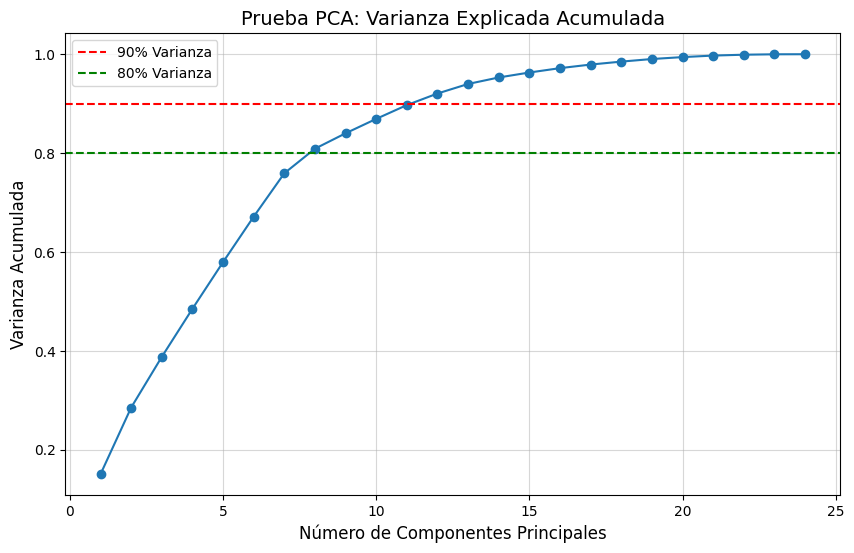

In [12]:
print(f"Dimensiones originales antes de PCA: {X_procesado.shape[1]}")

# 1. Ajustar el PCA con tantos componentes como columnas para analizar la varianza
pca_test = PCA(random_state=42) # Plantamos semilla para reproducibilidad
pca_test.fit(X_procesado)

# 2. Calcular la varianza explicada y la acumulada
explained_variance = pca_test.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 3. Determinar el umbral óptimo (Ej: 80% y 90%)
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Componentes para retener el 80% de la varianza: {n_components_80}")
print(f"Componentes para retener el 90% de la varianza: {n_components_90}")

# 4. Gráfico del Codo (Scree Plot) / Varianza Acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='#1f77b4')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.80, color='g', linestyle='--', label='80% Varianza')
plt.title('Prueba PCA: Varianza Explicada Acumulada', fontsize=14)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Acumulada', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Si nos fijamos en el gráfico vemos que la curva de la varianza explicada se empieza a suavizar cuando usamos 7 componentes y con 8 conseguimos explicar el 80% de la varianza.

Una vez determinado el número de componentes que queremos integrar en nuestro PCA vamos a realizar dos pruebas que determinarán la utilidad del PCA:

1. **Test de Esfericidad de Bartlett.** Confirma que la matriz de correlaciones de nuestras variables no es una identidad, es decir, que existen correlaciones suficientes que justifiquen la reducción de datos.
2. **Índice KMO.** Mide la calidad y fuerza de las correlaciones, compara las correlaciones observadas con las correlaciones parciales. Si las correlaciones parciales son pequeñas en comparación con las correlaciones originales, el índice será cercano a 1 y los factores estarán bien separados.

In [13]:
print("--- TEST DE ESFERICIDAD DE BARTLETT ---")

n = X_procesado.shape[0]
p = X_procesado.shape[1]
R = X_procesado.corr()
detR = np.linalg.det(R)

if detR > 0:
    statistic = -math.log(detR) * (n - 1 - (2*p + 5)/6)
    df_bartlett = p * (p - 1) / 2
    p_val = chi2.sf(statistic, df_bartlett)
    print(f"p-value del Test de Bartlett: {p_val:.4e}")
    print("Conclusión: Como p < 0.05, rechazamos H0. Es estadísticamente apropiado aplicar PCA.\n")


print("\n--- ÍNDICE KMO ---")
sys.path.append(os.path.abspath(os.path.join('..')))
from utils.function_tools import calculate_robust_kmo

kmo_global = calculate_robust_kmo(X_procesado)
print(f'Índice KMO: {kmo_global:.2f}')
if kmo_global >= 0.8:
    print("Conclusión: KMO Excelente.")
elif kmo_global >= 0.6:
    print("Conclusión: KMO Aceptable.")
else:
    print("Conclusión: KMO Inadecuado (< 0.6).")

--- TEST DE ESFERICIDAD DE BARTLETT ---
p-value del Test de Bartlett: 0.0000e+00
Conclusión: Como p < 0.05, rechazamos H0. Es estadísticamente apropiado aplicar PCA.


--- ÍNDICE KMO ---
Índice KMO: 0.29
Conclusión: KMO Inadecuado (< 0.6).


En vista del resultado del KMO determinamos que para nuestras variables las correlaciones son bastante difusas y no obtendremos un PCA de calidad. Esto se puede deber en parte a que el PCA es un análisis que funciona mejor con variables continuas y en concreto con aquellas que presentan normalidad. Este algoritmo no falla al usar variables binarias o con distribuciones distintas a la normal, sin embargo no será tan eficiente. 

Dado que nuestro conjunto de datos contiene no solo variables numéricas, también contiene categóricas que se han codificado en variables binarias probaremos a realizar un FAMD (_Factor Analysis of Mixed Data). Este algoritmo equilibra las contribuciones de cada tipo de variable para que ninguna domine a la otra y actúa como un PCA sobre las variables numéricas y como un MCA sobre las continuas; equilibrando matemáticamente la varianza continua y la inercia categórica para que un cambio en el nivel de una categórica tenga la misma oportunidad de influir en el que un cambio en una variable continua.

Para validar este algoritmo se usan dos coeficientes que se aplican una vez entrenado el modelo:

- Coeficiente de Determinación $R^{2}$. Para ver cuanto de las variables numéricas explica el modelo.
- Razón de Correlación $\eta^{2}$. Equivalente de la varianza explicada para las variables cualitativas.

En primer lugar, antes de ejecutar este modelo debemos de redefinir cuantos grupos son apropiados para nuestro análisis, para ello volvemos a usar el método del codo.

A la hora de ejecutar el FAMD no es necesario realizar tanto preprocesamiento como hicimos para ejecutar el PCA:  no es necesario codificar las variables categóricas ordinales pues el algoritmo detectara las distintas categorías, no es necesario estandarizar las numéricas pues el algoritmo las centra y reduce. Por otro lado debemos mantener las transformaciones logarítmicas y la codificación de las variables categóricas ordinales.

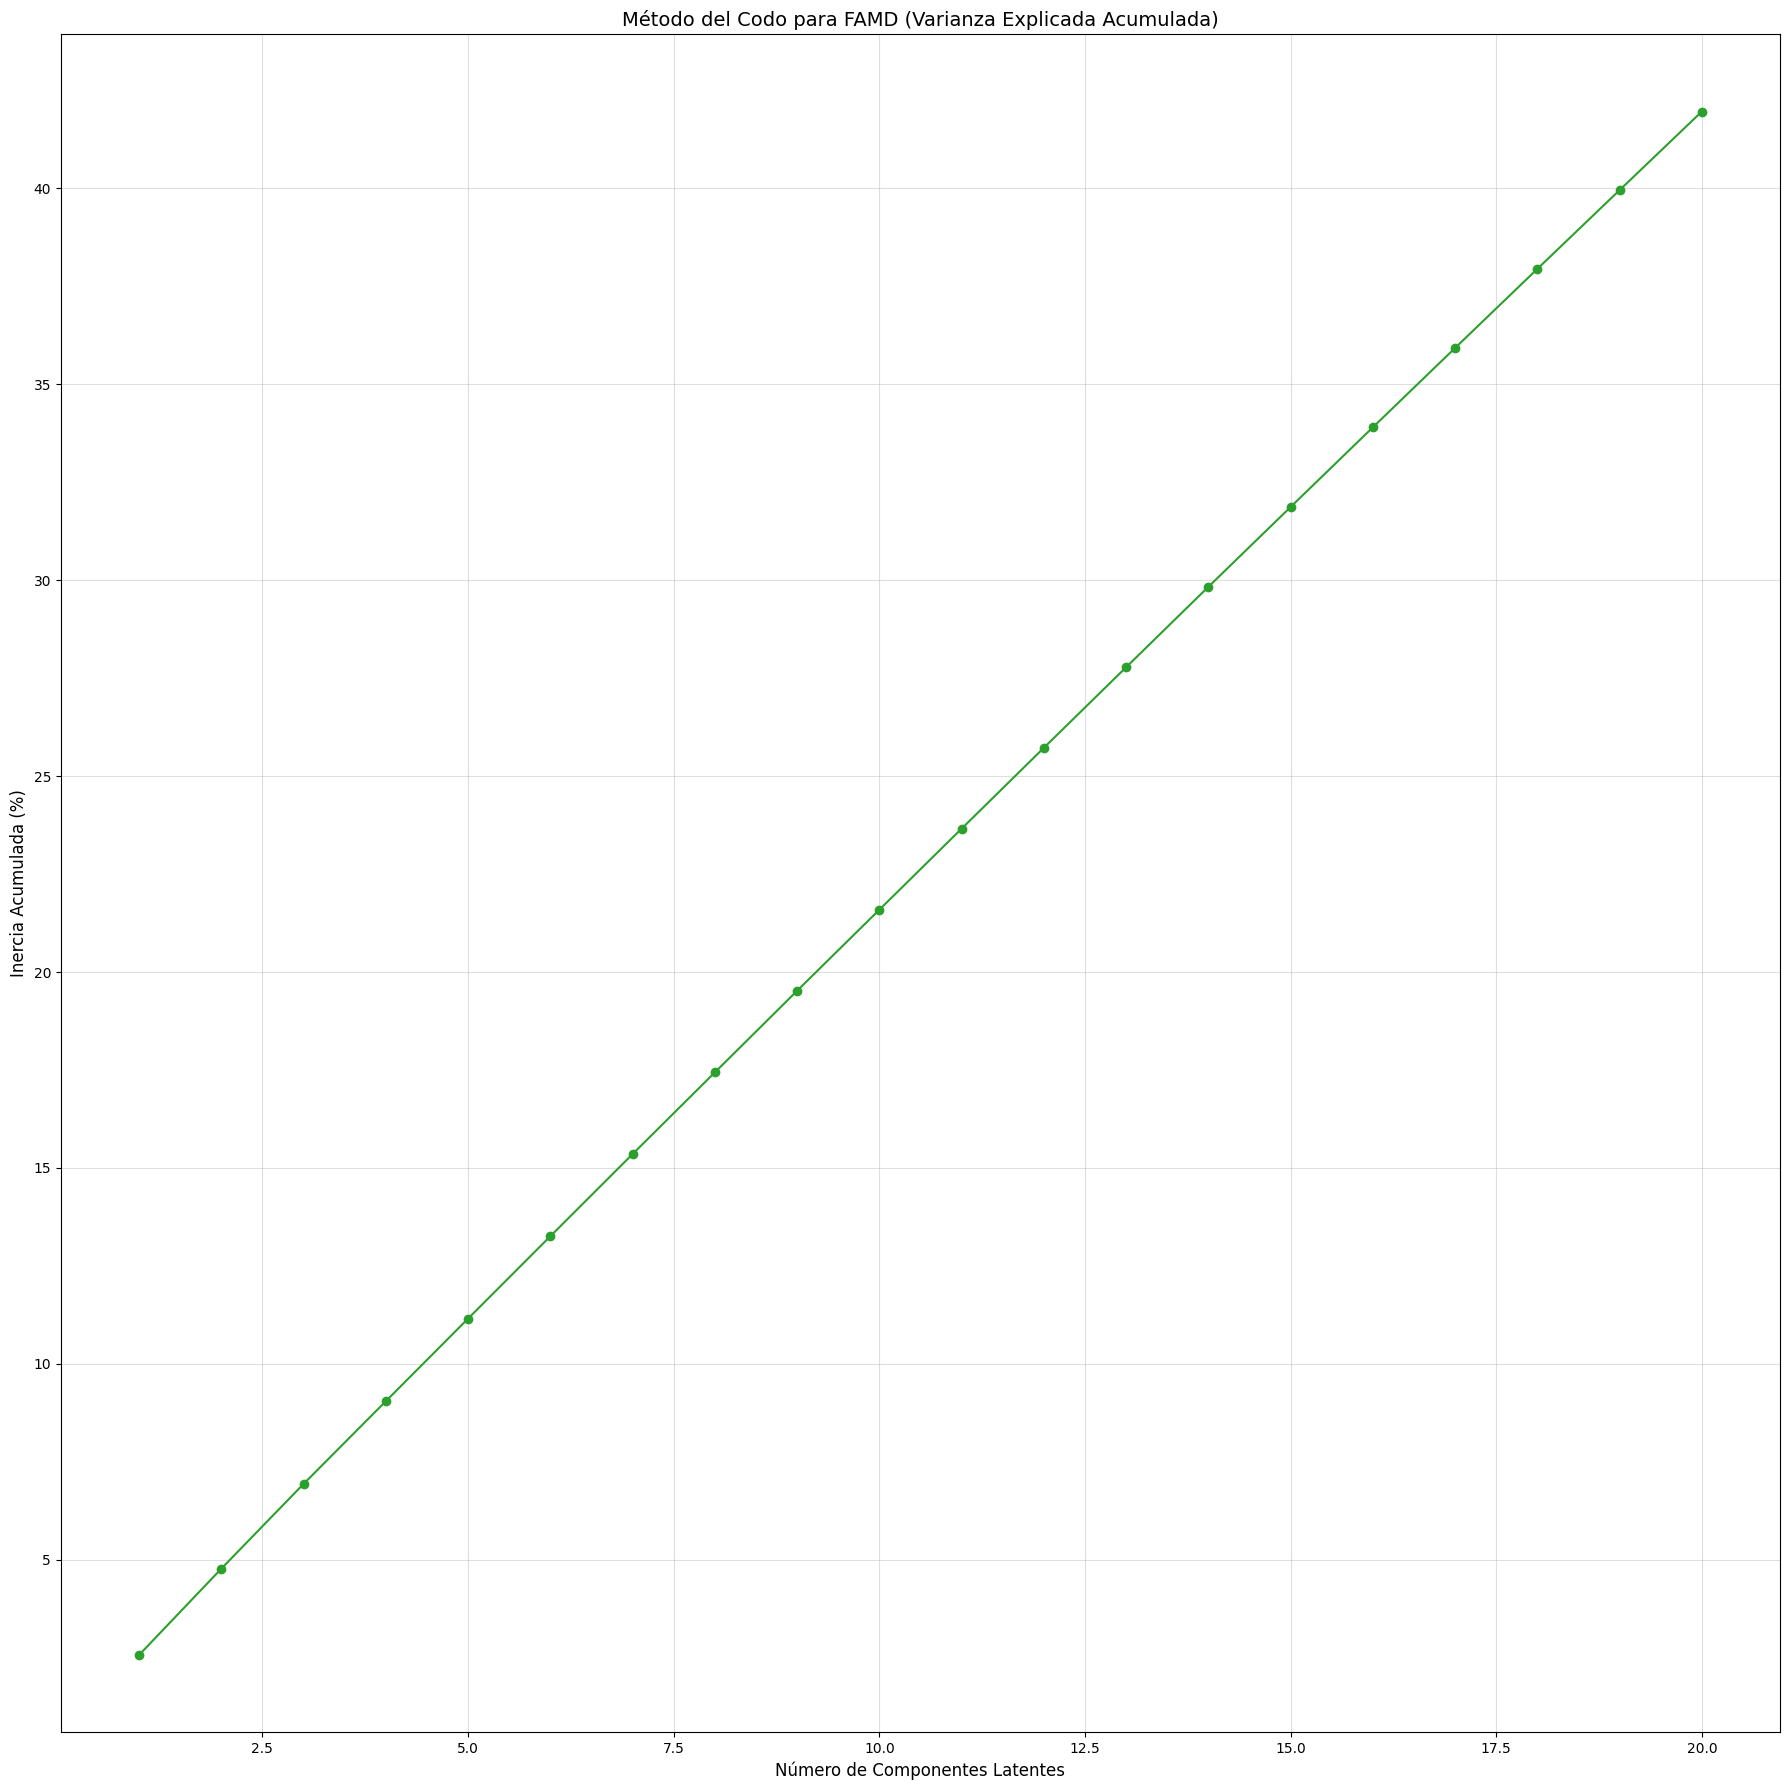

--- VARIANZA EXPLICADA POR EL MODELO FAMD ---
Componente 1: 2.57% (Acumulado: 2.57%)
Componente 2: 2.20% (Acumulado: 4.77%)
Componente 3: 2.16% (Acumulado: 6.94%)
Componente 4: 2.11% (Acumulado: 9.05%)
Componente 5: 2.11% (Acumulado: 11.16%)
Componente 6: 2.10% (Acumulado: 13.26%)
Componente 7: 2.10% (Acumulado: 15.35%)
Componente 8: 2.08% (Acumulado: 17.44%)
Componente 9: 2.08% (Acumulado: 19.52%)
Componente 10: 2.07% (Acumulado: 21.59%)
Componente 11: 2.07% (Acumulado: 23.66%)
Componente 12: 2.06% (Acumulado: 25.72%)
Componente 13: 2.06% (Acumulado: 27.78%)
Componente 14: 2.05% (Acumulado: 29.83%)
Componente 15: 2.04% (Acumulado: 31.87%)
Componente 16: 2.03% (Acumulado: 33.90%)
Componente 17: 2.03% (Acumulado: 35.93%)
Componente 18: 2.02% (Acumulado: 37.95%)
Componente 19: 2.01% (Acumulado: 39.96%)
Componente 20: 2.01% (Acumulado: 41.96%)


In [ ]:
# --- PREPROCESAMIENTO FAMD ---
df_FAMD = df.copy()

# 1.- Transformación logarítmica
cols_asim = ['Customer Lifetime Value', 'Monthly Premium Auto']

# Creamos las variables transformadas por la transformación logarítmica
for col in cols_asim:
    df_FAMD[f'{col}_log'] = np.log1p(df_FAMD[col])

df_FAMD = df_FAMD.drop(columns = cols_asim)

# 2.- Codificación ordinal
ordinal_cols = ['Coverage', 'Education', 'Vehicle Size']

# Cobertura: A mayor cobertura, mayor límite asegurado
dict_coverage = {'Basic': 0, 'Extended': 1, 'Premium': 2}
# Educación: Proxy de riesgo socioeconómico / aversión al riesgo
dict_education = {'High School or Below': 0, 'College': 1, 'Bachelor': 2, 'Master': 3, 'Doctor': 4}
# Tamaño del Vehículo: Correlaciona con el coste de reparación y severidad de daños materiales
dict_size = {'Small': 0, 'Medsize': 1, 'Large': 2}

df_FAMD['Coverage'] = df_FAMD['Coverage'].map(dict_coverage)
df_FAMD['Education'] = df_FAMD['Education'].map(dict_education)
df_FAMD['Vehicle Size'] = df_FAMD['Vehicle Size'].map(dict_size)

# --- SELECCIÓN del Nº de COMPONENTES ---
famd = prince.FAMD(
    n_components=20,                            # Usamos tantas componentes como variables hay para visualizar donde dobla el codo
    n_iter=10, copy=True, check_input=True,
    engine='sklearn', random_state=42
)

# Ajustamos el modelo a nuestros datos mixtos
famd = famd.fit(df_FAMD)

# Extraemos la varianza explicada por cada componente
explained_variance = famd.percentage_of_variance_
cumulative_variance = np.cumsum(explained_variance)


# --- VISUALIZACIÓN DEL SCREE PLOT ---
plt.figure(figsize=(10, 10))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance*100, marker='o', linestyle='-', color='#2ca02c')

plt.title('Método del Codo para FAMD (Varianza Explicada Acumulada)', fontsize=14)
plt.xlabel('Número de Componentes Latentes', fontsize=12)
plt.ylabel('Inercia Acumulada (%)', fontsize=12)


plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


Estuadiando el gráfico anterior observamos que cada nueva componente introduce un % casi constante cercano al 2% de varianza explicada, sin evidenciar una figura de codo que determinaría cual es el número apropiado de componentes bajo este análisis. Esto se traduce en que para nuestro conjunto de datos no es linealmente reducible la dimensionalidad sin caer en una perdida masiva de información pues el FAMD ha colapsado.

Se concluye que las variables predictoras de la severidad total poseen un lta independencia estructural. Si tratasemos de reducir la dimensionalidad con técnicas como PCA o FAMD incurriríamos en una destrucción arbitraria de la varianza del modelo. Por ello se descarta tratar de reducir el número de variables que particpan en nuestro modelo.

##### NEXT SETPS
HACER PCA(s) parcial(es), para generar índice(s) de variables correladas sin incluir variables con correlacion baja. 
Si funciona eliminar sección FAMD; si no funciona mantener sección y evitar reducción de la dimensionalidad.